# 🤖 WorldQuant BRAIN Alpha Mining Bot

LangGraph notebook สำหรับหา WorldQuant Alpha expressions แบบ minimal และรันครบลูปได้ก่อน

In [13]:
from typing import TypedDict
import os
import json
import time
import re
from pathlib import Path

import httpx
from langgraph.graph import END, START, StateGraph
from IPython.display import Image, display

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None

if load_dotenv is not None:
    load_dotenv(".env")

OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY", "")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1/chat/completions"

WQ_USERNAME = os.getenv("WQ_USERNAME", "")
WQ_PASSWORD = os.getenv("WQ_PASSWORD", "")
WQ_BASE_URL = "https://api.worldquantbrain.com"

SHARPE_TARGET = float(os.getenv("SHARPE_TARGET", "1.25"))
MAX_ALPHA_ITERATIONS = int(os.getenv("MAX_ALPHA_ITERATIONS", "20"))
SUCCESSFUL_ALPHAS_FILE = Path("successful_alphas.json")

OPENROUTER_MAX_RETRIES = int(os.getenv("OPENROUTER_MAX_RETRIES", "3"))
OPENROUTER_BASE_BACKOFF_SECONDS = float(os.getenv("OPENROUTER_BASE_BACKOFF_SECONDS", "1"))
OPENROUTER_REQUEST_PACING_SECONDS = float(os.getenv("OPENROUTER_REQUEST_PACING_SECONDS", "0.5"))

MODEL_MAP = {
    "hypothesis": "qwen/qwen3-30b-a3b-instruct-2507",
    "coder": "qwen/qwen3-30b-a3b-instruct-2507",
    "validator": "qwen/qwen3-30b-a3b-instruct-2507",
    "analyzer": "qwen/qwen3-30b-a3b-instruct-2507",
    "embedder": "qwen/qwen3-30b-a3b-instruct-2507",
}

MODEL_FALLBACKS = {
    "hypothesis": ["qwen/qwen3-30b-a3b-instruct-2507"],
    "coder": ["qwen/qwen3-30b-a3b-instruct-2507"],
    "validator": ["qwen/qwen3-30b-a3b-instruct-2507"],
    "analyzer": ["qwen/qwen3-30b-a3b-instruct-2507"],
    "embedder": ["qwen/qwen3-30b-a3b-instruct-2507"],
}

In [14]:
class AlphaMiningState(TypedDict):
    hypothesis: str
    alpha_expression: str
    validation_status: bool
    backtest_results: dict
    feedback: str
    iteration_count: int

In [15]:
def load_worldquant_meta_database(file_path="worldquant_meta_database.json"):
    path = Path(file_path)
    if not path.exists():
        return []

    with path.open("r", encoding="utf-8") as handle:
        data = json.load(handle)

    if isinstance(data, list):
        return data

    if isinstance(data, dict):
        return data.get("fields", []) or data.get("data", []) or []

    return []


def search_relevant_fields(keyword, limit=5, file_path="worldquant_meta_database.json"):
    metadata = load_worldquant_meta_database(file_path)
    keyword = keyword.lower().strip()
    matches = []

    if not keyword:
        return ["close", "open", "high", "low", "volume"][:limit]

    for item in metadata:
        if not isinstance(item, dict):
            continue

        searchable_text = " ".join(
            str(item.get(key, "")).lower() for key in ("name", "definition", "description", "category", "documentation")
        )

        if keyword in searchable_text:
            field_name = str(item.get("name", "")).strip()
            if field_name and field_name not in matches:
                matches.append(field_name)

        if len(matches) >= limit:
            break

    if matches:
        return matches[:limit]

    return ["close", "open", "high", "low", "volume"][:limit]


def call_openrouter(agent_key, user_prompt, system_prompt="You are a helpful quant assistant."):
    primary_model = MODEL_MAP[agent_key]
    fallback_models = MODEL_FALLBACKS.get(agent_key, [primary_model])
    models_to_try = []
    for model in [primary_model] + fallback_models:
        if model not in models_to_try:
            models_to_try.append(model)

    if not OPENROUTER_API_KEY:
        raise RuntimeError("OPENROUTER_API_KEY is missing; refusing to return mock text.")

    headers = {
        "Authorization": f"Bearer {OPENROUTER_API_KEY}",
        "Content-Type": "application/json",
    }

    last_error = None

    for model_name in models_to_try:
        for attempt in range(OPENROUTER_MAX_RETRIES):
            payload = {
                "model": model_name,
                "messages": [
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                "temperature": 0.2,
            }

            try:
                response = httpx.post(OPENROUTER_BASE_URL, headers=headers, json=payload, timeout=45.0)

                if response.status_code == 429:
                    wait_time = OPENROUTER_BASE_BACKOFF_SECONDS * (2 ** attempt)
                    print(f"⏳ Rate limit ({agent_key}, {model_name}) - retry in {wait_time:.1f}s")
                    time.sleep(wait_time)
                    last_error = RuntimeError(f"Rate limited by OpenRouter for {agent_key} using {model_name}")
                    continue

                response.raise_for_status()
                content = response.json().get("choices", [{}])[0].get("message", {}).get("content", "").strip()
                time.sleep(OPENROUTER_REQUEST_PACING_SECONDS)
                if content:
                    return content
                last_error = RuntimeError(f"Empty OpenRouter response for {agent_key} using {model_name}")
                break
            except Exception as exc:
                last_error = exc
                print(f"⚠️ OpenRouter Error ({agent_key}): {exc}")
                if attempt < OPENROUTER_MAX_RETRIES - 1:
                    wait_time = OPENROUTER_BASE_BACKOFF_SECONDS * (2 ** attempt)
                    time.sleep(wait_time)
                else:
                    print(f"↪️ Switching model for {agent_key} after retries: {model_name}")

    raise RuntimeError(f"OpenRouter request failed for {agent_key}; last error: {last_error}")

In [16]:
def generate_hypothesis(state):
    time.sleep(10)
    print(f"Running generate_hypothesis with model: {MODEL_MAP['hypothesis']}")
    iteration_count = state.get("iteration_count", 0) + 1
    feedback = state.get("feedback", "").strip()
    prompt = f"Generate one concise alpha hypothesis. Feedback: {feedback or 'none'}"
    hypothesis_text = call_openrouter("hypothesis", prompt, "You generate alpha research hypotheses.")

    print(f"💡 New Hypothesis: {hypothesis_text}")

    return {
        "hypothesis": hypothesis_text,
        "iteration_count": iteration_count,
    }


def code_alpha(state):
    time.sleep(10)
    print(f"Running code_alpha with model: {MODEL_MAP['coder']}")
    hypothesis = state.get("hypothesis", "")
    fields = search_relevant_fields(hypothesis)
    field_hint = ", ".join(fields)

    prompt = (
        f"Hypothesis: {hypothesis}\n"
        f"Available fields: {field_hint}\n"
        "Valid Operators Cheat Sheet:\n"
        "Time Series: ts_delay(x, d), ts_delta(x, d), ts_sum(x, d), ts_mean(x, d), ts_std(x, d), ts_rank(x, d), ts_max(x, d), ts_min(x, d)\n"
        "Cross Sectional: rank(x), scale(x), zscore(x)\n"
        "Arithmetic: log(x), abs(x), sign(x)\n"
        "CRITICAL RULE: You must write ONLY a SINGLE, continuous inline mathematical expression.\n"
        "NO variable assignments. NO newlines. NO semicolons. NO markdown tags.\n"
        "If you want to calculate returns, use (x / ts_delay(x, d) - 1). Do NOT use ts_return.\n"
        "Ensure all functions follow the exact names listed in the Cheat Sheet.\n"
        "COMPLEXITY LIMIT: Your expression must be concise. Do NOT exceed 40 operators. Simple and robust formulas are preferred over overly complex ones.\n"
        "PUNISHMENT: If the expression is too long, the simulation will fail. Focus on the most impactful data fields and operators.\n"
        "EXAMPLE GOOD 1: rank(ts_sum(close, 30) / ts_mean(volume, 20))\n"
        "EXAMPLE GOOD 2: (close - ts_delay(close, 1)) / close\n"
        "OUTPUT THE EXPRESSION ONLY:"
    )

    alpha_expression = call_openrouter("coder", prompt, "You are an expert WorldQuant FASTEXPR coder.")

    # ล้าง Markdown blocks ที่ AI ชอบแถมมาให้ (เช่น ```python ... ```)
    alpha_expression = alpha_expression.replace("```python", "").replace("```alpha", "").replace("```", "").strip()

    # ลบการขึ้นบรรทัดใหม่ให้เหลือบรรทัดเดียว
    alpha_expression = " ".join(alpha_expression.splitlines())

    print(f"💻 Generated Alpha: {alpha_expression}")

    return {
        "alpha_expression": alpha_expression,
        "validation_status": False,
    }


def validate_alpha(state):
    time.sleep(10)
    print(f"Running validate_alpha with model: {MODEL_MAP['validator']}")
    alpha_expression = state.get("alpha_expression", "").strip()
    alpha_lower = alpha_expression.lower()

    is_valid = True
    feedback_msg = ""

    # ด่านตรวจจับ Syntax ต้องห้ามสำหรับ FASTEXPR
    if not alpha_expression:
        is_valid = False
        feedback_msg = "Error: Expression is empty."
    elif "\n" in alpha_expression or "=" in alpha_expression or ";" in alpha_expression:
        is_valid = False
        feedback_msg = "Error: Variable assignments (=), semicolons (;), and newlines are STRICTLY FORBIDDEN. Write a single nested expression."
    elif any(bad_op in alpha_lower for bad_op in ("ts_return", "ts_minimum", "ts_maximum")):
        is_valid = False
        feedback_msg = "Used invalid operator. Use ts_min/ts_max instead of ts_minimum/ts_maximum and manual calculation for returns."
    else:
        function_calls = len(re.findall(r"\b[a-zA-Z_][a-zA-Z0-9_]*\s*\(", alpha_expression))
        symbol_ops = sum(alpha_expression.count(op) for op in ["+", "-", "*", "/"])
        paren_count = alpha_expression.count("(")
        estimated_ops = function_calls + symbol_ops + paren_count
        if estimated_ops > 60:
            is_valid = False
            feedback_msg = "Expression is too complex (near 64 operator limit). Please simplify the formula."
        else:
            # ถ้าผ่านด่านพื้นฐาน ค่อยให้ AI ช่วยเช็คอีกรอบ
            _ = call_openrouter(
                "validator",
                f"Check this alpha expression syntax: {alpha_expression}",
                "You validate alpha syntax quickly.",
            )
            feedback_msg = ""

    print(f"🔎 Validation Passed: {is_valid} | Feedback: {feedback_msg}")

    return {
        "validation_status": is_valid,
        "feedback": feedback_msg if not is_valid else "",
    }


def run_backtest(state):
    time.sleep(10)
    print("Running run_backtest")
    expression = state.get("alpha_expression", "").strip()

    def _to_float(value):
        if isinstance(value, str):
            cleaned = value.strip().replace("%", "")
            if not cleaned:
                return 0.0
            try:
                numeric = float(cleaned)
                return numeric / 100.0 if "%" in value else numeric
            except ValueError:
                return 0.0
        try:
            return float(value)
        except (TypeError, ValueError):
            return 0.0

    fail_result = {
        "backtest_results": {
            "sharpe": 0.0,
            "turnover": 0.0,
            "fitness": 0.0,
        }
    }

    if not expression:
        print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
        return fail_result

    if not WQ_USERNAME or not WQ_PASSWORD:
        print("⚠️ WQ Credentials missing!")
        print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
        return fail_result

    simulation_payload = {
        "type": "REGULAR",
        "settings": {
            "instrumentType": "EQUITY",
            "region": "USA",
            "universe": "TOP3000",
            "delay": 1,
            "decay": 2,
            "neutralization": "SUBINDUSTRY",
            "truncation": 0.08,
            "pasteurization": "ON",
            "unitHandling": "VERIFY",
            "nanHandling": "ON",
            "language": "FASTEXPR",
            "visualization": False,
        },
        "regular": expression,
    }

    try:
        with httpx.Client(timeout=30.0) as client:
            auth_resp = client.post(
                f"{WQ_BASE_URL}/authentication",
                auth=(WQ_USERNAME, WQ_PASSWORD),
            )
            if auth_resp.status_code != 201:
                print(f"⚠️ WQ Auth Error: {auth_resp.text}")
                print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
                return fail_result

            sim_resp = client.post(
                f"{WQ_BASE_URL}/simulations",
                json=simulation_payload,
            )
            if sim_resp.status_code != 201:
                print(f"Simulation submit failed: {sim_resp.status_code} | {sim_resp.text}")
                print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
                return fail_result

            status_url = sim_resp.headers.get("Location", "")
            if not status_url:
                print("Simulation status URL not found")
                print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
                return fail_result

            if status_url.startswith("/"):
                status_url = f"{WQ_BASE_URL}{status_url}"

            for _ in range(60):
                status_resp = client.get(status_url)
                status_resp.raise_for_status()
                status_data = status_resp.json()
                status = str(status_data.get("status", "")).upper()

                if status == "COMPLETE":
                    stats = status_data.get("is", {})
                    metrics = {
                        "sharpe": _to_float(stats.get("sharpe", 0)),
                        "turnover": _to_float(stats.get("turnover", 0)),
                        "fitness": _to_float(stats.get("fitness", 0)),
                    }
                    print(
                        f"📊 Backtest Results -> Sharpe: {metrics.get('sharpe')}, "
                        f"Fitness: {metrics.get('fitness')}, Turnover: {metrics.get('turnover')}"
                    )
                    return {
                        "backtest_results": metrics
                    }

                if status == "ERROR":
                    print("⚠️ WQ Simulation returned ERROR status.")
                    print(json.dumps(status_data, indent=2, ensure_ascii=False))
                    print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
                    return fail_result

                time.sleep(2)

            print("Simulation polling timed out")
            print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
            return fail_result

    except Exception as exc:
        print(f"run_backtest error: {exc}")
        print("📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0")
        return fail_result


def analyze_results(state):
    time.sleep(10)
    print(f"Running analyze_results with model: {MODEL_MAP['analyzer']}")
    sharpe = float(state.get("backtest_results", {}).get("sharpe", 0))

    if sharpe > SHARPE_TARGET:
        success_entry = {
            "alpha_expression": state.get("alpha_expression", ""),
            "hypothesis": state.get("hypothesis", ""),
            "backtest_results": state.get("backtest_results", {}),
        }

        try:
            if SUCCESSFUL_ALPHAS_FILE.exists():
                with SUCCESSFUL_ALPHAS_FILE.open("r", encoding="utf-8") as infile:
                    existing = json.load(infile)
                if not isinstance(existing, list):
                    existing = []
            else:
                existing = []
        except Exception:
            existing = []

        existing.append(success_entry)
        with SUCCESSFUL_ALPHAS_FILE.open("w", encoding="utf-8") as outfile:
            json.dump(existing, outfile, ensure_ascii=False, indent=2)

        print(f"✅ Saved successful alpha to {SUCCESSFUL_ALPHAS_FILE}")

    _ = call_openrouter(
        "analyzer",
        f"Analyze result with sharpe={sharpe} and suggest next action.",
        "You analyze alpha backtest metrics.",
    )

    feedback = "" if sharpe > SHARPE_TARGET else "Sharpe below target. Try a new hypothesis."
    print(f"🧠 Analyzer Feedback: {feedback}")

    return {
        "feedback": feedback,
    }

In [17]:
def route_after_validation(state):
    if not state.get("validation_status", False):
        return "code_alpha"
    return "run_backtest"


def route_after_analysis(state):
    if state.get("iteration_count", 0) >= MAX_ALPHA_ITERATIONS:
        return END

    return "generate_hypothesis"


workflow = StateGraph(AlphaMiningState)
workflow.add_node("generate_hypothesis", generate_hypothesis)
workflow.add_node("code_alpha", code_alpha)
workflow.add_node("validate_alpha", validate_alpha)
workflow.add_node("run_backtest", run_backtest)
workflow.add_node("analyze_results", analyze_results)

workflow.add_edge(START, "generate_hypothesis")
workflow.add_edge("generate_hypothesis", "code_alpha")
workflow.add_edge("code_alpha", "validate_alpha")

workflow.add_conditional_edges(
    "validate_alpha",
    route_after_validation,
    {
        "code_alpha": "code_alpha",
        "run_backtest": "run_backtest",
    },
)

workflow.add_edge("run_backtest", "analyze_results")
workflow.add_conditional_edges(
    "analyze_results",
    route_after_analysis,
    {
        "generate_hypothesis": "generate_hypothesis",
        END: END,
    },
)

app = workflow.compile()

In [18]:
initial_state = {
    "hypothesis": "",
    "alpha_expression": "",
    "validation_status": False,
    "backtest_results": {},
    "feedback": "",
    "iteration_count": 0,
}

config = {"recursion_limit": 1000}

final_state = app.invoke(initial_state, config=config)
print(json.dumps(final_state, indent=2, ensure_ascii=False))

Running generate_hypothesis with model: qwen/qwen3-30b-a3b-instruct-2507
💡 New Hypothesis: Firms with higher ESG scores exhibit statistically significant abnormal returns over the subsequent 12 months, particularly in sectors with high regulatory scrutiny.
Running code_alpha with model: qwen/qwen3-30b-a3b-instruct-2507
💻 Generated Alpha: rank(ts_mean(ts_delay(close, 12) / close - 1, 12)) * zscore(ts_rank(volume, 20))
Running validate_alpha with model: qwen/qwen3-30b-a3b-instruct-2507
🔎 Validation Passed: True | Feedback: 
Running run_backtest
📊 Backtest Results -> Sharpe: 0.0, Fitness: 0.0, Turnover: 0.0
Running analyze_results with model: qwen/qwen3-30b-a3b-instruct-2507
🧠 Analyzer Feedback: Sharpe below target. Try a new hypothesis.
Running generate_hypothesis with model: qwen/qwen3-30b-a3b-instruct-2507
💡 New Hypothesis: Alpha Hypothesis:  
A long-only portfolio weighted by momentum (6-month price return) and inverse volatility (inverse of 60-day rolling volatility), rebalanced mont

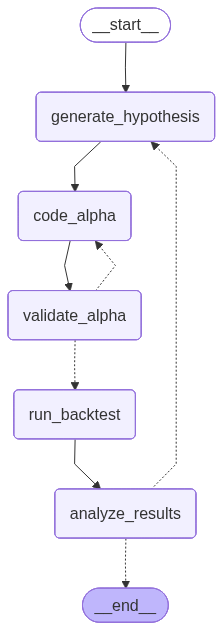

In [19]:
display(Image(app.get_graph().draw_mermaid_png()))